# [20480-02 Artificial Intelligence]<br>Assignment 1
## Part 2. Implementing Neural Networks from Scratch

Modified by Yujin Oh, Artificial General Intelligence Laboratory, Ewha Womans University (Adapted from DSAIL at SNU).
This material is for educational uses only. Some contents are based on the material provided by other paper/book authors and may be copyrighted by them.

Previously in `Assignment1-1_Data_Curation.ipynb`, we created a pickle with formatted datasets for training, development and testing on the [notMNIST dataset](http://yaroslavvb.blogspot.com/2011/09/notmnist-dataset.html).

The goal of this assignment is to implement a simple 3-layer neural network from scratch. We won't derive all the math that's required, but I will try to give an intuitive explanation of what we are doing and will point to resources to read up on the details.

But why implement a Neural Network from scratch at all? Even if you plan on using Neural Network libraries like [PyBrain](http://pybrain.org) in the future, implementing a network from scratch at least once is an extremely valuable exercise. It helps you gain an understanding of how neural networks work, and that is essential to designing effective models.

One thing to note is that the code examples here aren't terribly efficient. They are meant to be easy to understand. In an upcoming part of the assignment, we will explore how to write an efficient Neural Network implementation using [PyTorch](http://pytorch.org/).

**Note**: certain details are missing or ambiguous on purpose, in order to test your knowledge on the related materials. However, if you really feel that something essential is missing and cannot proceed to the next step, then contact the teaching staff with clear description of your problem.

### Submitting your work:
<font color=red>**DO NOT clear the final outputs**</font> so that TAs can grade both your code and results.  

## Load datasets

First reload the data we generated in `Assignment2-1_Data_Curation.ipynb`.

In [2]:
# These are all the modules we'll be using later. Make sure you can import them
# before proceeding further.
import numpy as np
from six.moves import cPickle as pickle
from six.moves import range
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline


In [3]:
# Restore notMNIST pickle from Google Drive (Required for Part 2/3)

import os, shutil
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# e.g. DRIVE_PATH = '2026_01_AI/assignment1'
DRIVE_PATH = '2026_01_AI/assignment1'

assert DRIVE_PATH is not None, "[!] Enter the foldername in your Drive."

# Paths
local_pickle = os.path.join('data', 'notMNIST.pickle')
drive_pickle = f'/content/drive/MyDrive/{DRIVE_PATH}/notMNIST.pickle'

os.makedirs('data', exist_ok=True)

# Check existence in Drive
assert os.path.exists(drive_pickle), \
"[!] Pickle not found in Drive. Run Part 1 first."

# Copy to runtime
shutil.copy2(drive_pickle, local_pickle)

print("Restored from Drive:", drive_pickle)
print("Local path:", local_pickle)


Mounted at /content/drive
Restored from Drive: /content/drive/MyDrive/2026_01_AI/assignment1/notMNIST.pickle
Local path: data/notMNIST.pickle


In [4]:
pickle_file = 'data/notMNIST.pickle'

with open(pickle_file, 'rb') as f:
    save = pickle.load(f)
    train_dataset = save['train_dataset']
    train_labels = save['train_labels']
    valid_dataset = save['valid_dataset']
    valid_labels = save['valid_labels']
    test_dataset = save['test_dataset']
    test_labels = save['test_labels']
    del save  # hint to help gc free up memory
    print('Training set', train_dataset.shape, train_labels.shape)
    print('Validation set', valid_dataset.shape, valid_labels.shape)
    print('Test set', test_dataset.shape, test_labels.shape)

Training set (12000, 28, 28) (12000,)
Validation set (2000, 28, 28) (2000,)
Test set (2000, 28, 28) (2000,)


Reformat into a shape that's more adapted to the models we're going to train:
- unnormalize data
- data as a flat matrix,
- labels as float 1-hot encodings.

In [5]:
image_size = 28
num_labels = 10

def reformat(dataset, labels):
    dataset = dataset * 255.0 + 255.0/2
    dataset = dataset.reshape((-1, image_size * image_size)).astype(np.float32)
    # one-hot encoding, Map the label 0 to [1.0, 0.0, 0.0 ...], 1 to [0.0, 1.0, 0.0 ...]
    labels = (np.arange(num_labels) == labels[:,None]).astype(np.float32)
    return dataset, labels

train_dataset, train_labels = reformat(train_dataset, train_labels)
valid_dataset, valid_labels = reformat(valid_dataset, valid_labels)
test_dataset, test_labels = reformat(test_dataset, test_labels)
print('Training set', train_dataset.shape, train_labels.shape)
print('Validation set', valid_dataset.shape, valid_labels.shape)
print('Test set', test_dataset.shape, test_labels.shape)

Training set (12000, 784) (12000, 10)
Validation set (2000, 784) (2000, 10)
Test set (2000, 784) (2000, 10)


In [6]:
data_size = 2000
train_dataset = train_dataset[0:data_size]
train_labels = train_labels[0:data_size]

## Training a Neural Network

Sample network


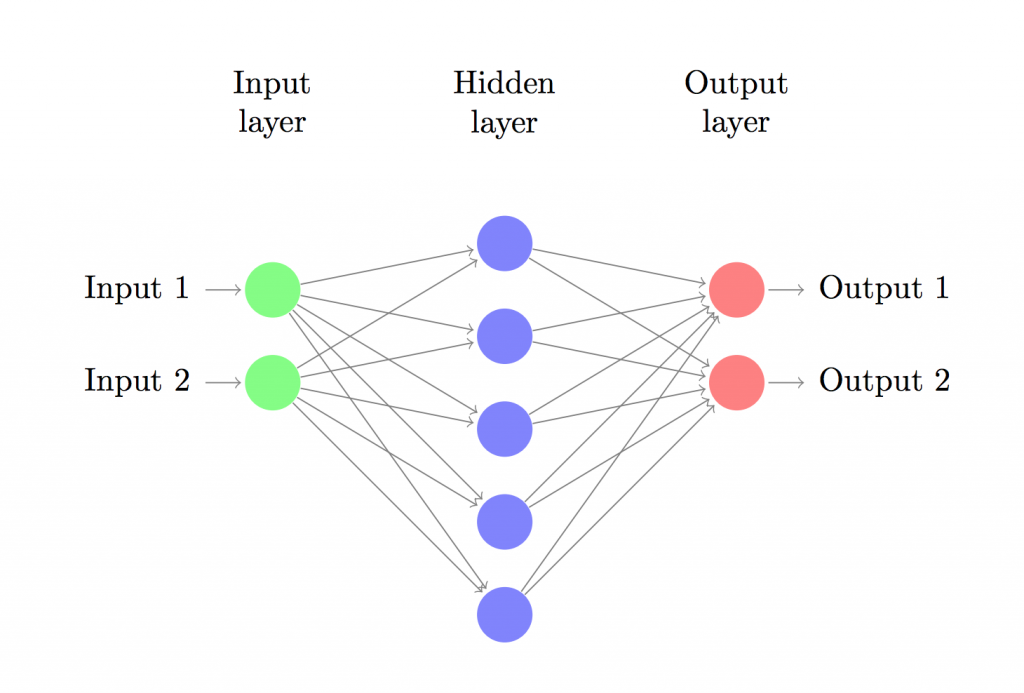

In [7]:
# Load Sample Network image
sample_net_img_path = f'/content/drive/MyDrive/{DRIVE_PATH}/Utils/nn-from-scratch-3-layer-network-1024x693.png'
from PIL import Image
from IPython.display import display

print("Sample network")
display(Image.open(sample_net_img_path))

Let's now build a neural network with one input layer, one hidden layer, and one output layer. The number of nodes in the input layer is determined by the dimensionality of our data, 784. Similarly, the number of nodes in the output layer is determined by the number of classes we have, 10. The input to the network will be the pixel values of the input image and its output will be ten probabilities, ones for each class.

### How our network makes predictions

Our network makes predictions using *forward propagation*, which is just a bunch of matrix multiplications and the application of the activation function(s) we defined above. If $x$ is the 784-dimensional input to our network then we calculate our prediction $\hat{y}$ (ten-dimensional) as follows:

$$
\begin{aligned}
z_1 & = xW_1 + b_1 \\
a_1 & = \tanh(z_1) \\
z_2 & = a_1W_2 + b_2 \\
a_2 & = \hat{y} = \mathrm{softmax}(z_2)
\end{aligned}
$$

$z_i$ is the input of layer $i$ and $a_i$ is the output of layer $i$ after applying the activation function. $W_1, b_1, W_2, b_2$ are  parameters of our network, which we need to learn from our training data. You can think of them as matrices transforming data between layers of the network. Looking at the matrix multiplications above we can figure out the dimensionality of these matrices. If we use 1024 nodes for our hidden layer then $W_1 \in \mathbb{R}^{784\times1024}$, $b_1 \in \mathbb{R}^{1024}$, $W_2 \in \mathbb{R}^{1024\times10}$, $b_2 \in \mathbb{R}^{10}$. Now you see why we have more parameters if we increase the size of the hidden layer.

### Learning the Parameters

Learning the parameters for our network means finding parameters ($W_1, b_1, W_2, b_2$) that minimize the error on our training data. But how do we define the error? We call the function that measures our error the *loss function*. A common choice with the softmax output is the [cross-entropy loss](https://en.wikipedia.org/wiki/Cross_entropy#Cross-entropy_error_function_and_logistic_regression). If we have $N$ training examples and $C$ classes then the loss for our prediction $\hat{y}$ with respect to the true labels $y$ is given by:

$$
\begin{aligned}
L(y,\hat{y}) = - \frac{1}{N} \sum_{n \in N} \sum_{i \in C} y_{n,i} \log\hat{y}_{n,i}
\end{aligned}
$$



The formula looks complicated, but all it really does is sum over our training examples and add to the loss if we predicted the incorrect class. So, the further away $y$ (the correct labels) and $\hat{y}$ (our predictions) are, the greater our loss will be.

Remember that our goal is to find the parameters that minimize our loss function. We can use [gradient descent](http://cs231n.github.io/optimization-1/) to find its minimum. I will implement the most vanilla version of gradient descent, also called batch gradient descent with a fixed learning rate. Variations such as SGD (stochastic gradient descent) or minibatch gradient descent typically perform better in practice. So if you are serious you'll want to use one of these, and ideally you would also [decay the learning rate over time](http://cs231n.github.io/neural-networks-3/#anneal).

As an input, gradient descent needs the gradients (vector of derivatives) of the loss function with respect to our parameters: $\frac{\partial{L}}{\partial{W_1}}$, $\frac{\partial{L}}{\partial{b_1}}$, $\frac{\partial{L}}{\partial{W_2}}$, $\frac{\partial{L}}{\partial{b_2}}$. To calculate these gradients we use the famous *backpropagation algorithm*, which is a way to efficiently calculate the gradients starting from the output. I won't go into detail how backpropagation works, but there are many excellent explanations ([here](http://colah.github.io/posts/2015-08-Backprop/) or [here](http://cs231n.github.io/optimization-2/)) floating around the web.

Applying the backpropagation formula we find the following (trust me on this):

$$
\begin{aligned}
& \delta_3 = \hat{y} - y \\
& \delta_2 = (1 - \tanh^2z_1) \circ \delta_3W_2^T \\
& \frac{\partial{L}}{\partial{W_2}} = a_1^T \delta_3  \\
& \frac{\partial{L}}{\partial{b_2}} = \delta_3\\
& \frac{\partial{L}}{\partial{W_1}} = x^T \delta_2\\
& \frac{\partial{L}}{\partial{b_1}} = \delta_2 \\
\end{aligned}
$$

### Activations functions

There are various activation functions in neural networks.
According to the characteristics of each activation function, the type of the neural network, and the data type, appropriate activation functions are used.




Activations functions


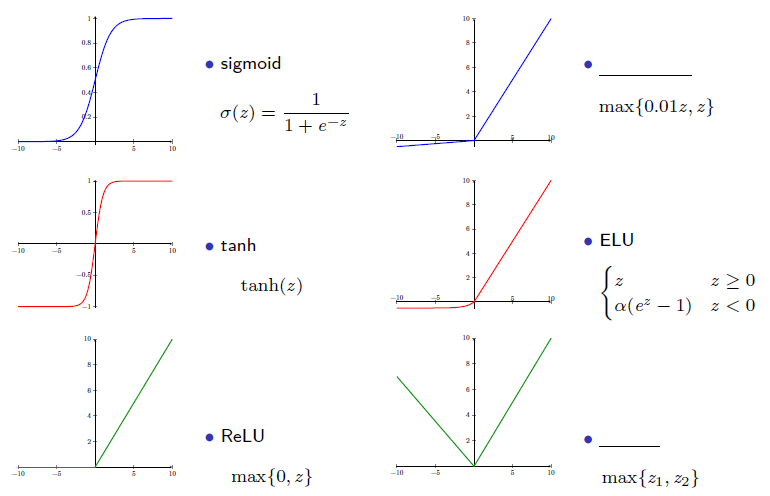

In [8]:
# Load Activations functions image
activations_ftn_img_path = f'/content/drive/MyDrive/{DRIVE_PATH}/Utils/activation-functions.png'

print("Activations functions")
display(Image.open(activations_ftn_img_path))

## Implementation

Now we are ready for our implementation. We start by defining some useful variables and parameters for gradient descent:

In [9]:
num_examples = len(train_dataset) # training set size
nn_input_dim = 784 # input layer dimensionality
nn_output_dim = 10 # output layer dimensionality

# Gradient descent parameters (I picked these by hand)
epsilon = 0.01 # learning rate for gradient descent
reg_lambda = 0.01 # regularization strength

### Loss function

First let's implement the loss function we defined above. We use this to evaluate how well our model is doing:

In [10]:
# Helper function to evaluate the total loss on the dataset
def calculate_loss(model):
    W1, b1, W2, b2 = model['W1'], model['b1'], model['W2'], model['b2']
    # Forward propagation to calculate our predictions
    z1 = train_dataset.dot(W1) + b1
    a1 = np.tanh(z1)
    z2 = a1.dot(W2) + b2
    exp_scores = np.exp(z2)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    # Calculating the loss
    corect_logprobs = -np.log([probs[i,np.nonzero(train_labels)[(1)][i].astype('int64')] for i in range(num_examples)])
    data_loss = np.sum(corect_logprobs)
    # Add regulatization term to loss (optional)
    data_loss += reg_lambda/2 * (np.sum(np.square(W1)) + np.sum(np.square(W2)))
    return 1./num_examples * data_loss

We also implement a helper function to calculate the output of the network. It does forward propagation as defined above and returns the class with the highest probability.

In [11]:
# Helper function to predict an output (0 or 1)
def predict(model, x):
    W1, b1, W2, b2 = model['W1'], model['b1'], model['W2'], model['b2']
    # Forward propagation
    z1 = x.dot(W1) + b1
    a1 = np.tanh(z1)
    z2 = a1.dot(W2) + b2
    exp_scores = np.exp(z2)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    return np.argmax(probs, axis=1)

## Build model
Finally, here comes the function to train our Neural Network. It implements batch gradient descent using the backpropagation derivates we found above

In [12]:
# This function learns parameters for the neural network and returns the model.
# - nn_hdim: Number of nodes in the hidden layer
# - num_passes: Number of passes through the training data for gradient descent
# - print_loss: If True, print the loss every 1000 iterations
def build_model(nn_hdim, num_passes=10000, print_loss=False):

    # Initialize the parameters to random values. We need to learn these.
    np.random.seed(0)
    W1 = np.random.randn(nn_input_dim, nn_hdim) / np.sqrt(nn_input_dim)
    b1 = np.zeros((1, nn_hdim))
    W2 = np.random.randn(nn_hdim, nn_output_dim) / np.sqrt(nn_hdim)
    b2 = np.zeros((1, nn_output_dim))

    # This is what we return at the end
    model = {}

    # Gradient descent. For each batch...
    for i in range(0, num_passes):

        # Forward propagation
        z1 = train_dataset.dot(W1) + b1
        a1 = np.tanh(z1)
        z2 = a1.dot(W2) + b2
        exp_scores = np.exp(z2)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

        # Backpropagation
        delta3 = (probs - train_labels) / data_size
        dW2 = (a1.T).dot(delta3)
        db2 = np.sum(delta3, axis=0, keepdims=True)
        delta2 = delta3.dot(W2.T) * (1 - np.power(a1, 2))
        dW1 = np.dot(train_dataset.T, delta2)
        db1 = np.sum(delta2, axis=0)

        # Add regularization terms (b1 and b2 don't have regularization terms)
        dW2 += reg_lambda * W2
        dW1 += reg_lambda * W1

        # Gradient descent parameter update
        W1 += -epsilon * dW1
        b1 += -epsilon * db1
        W2 += -epsilon * dW2
        b2 += -epsilon * db2

        # Assign new parameters to the model
        model = { 'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}

        # Optionally print the loss.
        # This is expensive because it uses the whole dataset, so we don't want to do it too often.
        if print_loss and i % 1000 == 0:
            print("Loss after iteration %i: %f" %(i, calculate_loss(model)))

    return model

## A network with a hidden layer of size 10

Let's see what happens if we train a network with a hidden layer size of 10.

In [13]:
# Build a model with a 10-dimensional hidden layer
model = build_model(10, num_passes=5000,print_loss=True)

Loss after iteration 0: 2.409001
Loss after iteration 1000: 0.722426
Loss after iteration 2000: 0.506435
Loss after iteration 3000: 0.417570
Loss after iteration 4000: 0.367612


# Varying the hidden layer size

In the example above we picked a hidden layer size of 10. Let's now get a sense of how varying the hidden layer size affects the result.


In [14]:
hidden_layer_dimensions = [50, 100]
for i, nn_hdim in enumerate(hidden_layer_dimensions):
    model = build_model(nn_hdim,num_passes=5000, print_loss=True)

Loss after iteration 0: 2.345204
Loss after iteration 1000: 0.430458
Loss after iteration 2000: 0.331880
Loss after iteration 3000: 0.285247
Loss after iteration 4000: 0.255840
Loss after iteration 0: 2.323605
Loss after iteration 1000: 0.410738
Loss after iteration 2000: 0.321999
Loss after iteration 3000: 0.278298
Loss after iteration 4000: 0.250167


We can see that while a hidden layer of low dimensionality nicely capture the general trend of our data, but higher dimensionalities are prone to overfitting. They are "memorizing" the data as opposed to fitting the general shape. If we were to evaluate our model on a separate test set (and you should!) the model with a smaller hidden layer size would likely perform better because it generalizes better. We could counteract overfitting with stronger regularization, but picking the a correct size for hidden layer is a much more "economical" solution.

---
## Problem

Implement neural network with a <font color='red'>$two\ hidden\ layer$</font> to improve your model's validation / test accuracy as much as you can. You just can copy and paste the code above, but I strongly recommend you to implement it yourself.

Here are some things you can try:

1. Instead of batch gradient descent, use **minibatch** gradient descent ([more info](http://cs231n.github.io/optimization-1/#gd)) to train the network. Minibatch gradient descent typically performs better in practice.
2. We used a fixed learning rate epsilon for gradient descent. Implement an **annealing** schedule for the gradient descent learning rate ([more info](http://cs231n.github.io/neural-networks-3/#anneal)).
3. We used a tanh activation function for our hidden layer. Experiment with other activation functions such as **ReLU** function. Note that changing the activation function also means changing the backpropagation derivative.

**Evaluation**: Use print_loss option and show the model actually train.

---

In [15]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(np.float32)

def calculate_loss_two_hidden(model):
    W1, b1 = model['W1'], model['b1']
    W2, b2 = model['W2'], model['b2']
    W3, b3 = model['W3'], model['b3']

    z1 = train_dataset.dot(W1) + b1
    a1 = relu(z1)
    z2 = a1.dot(W2) + b2
    a2 = relu(z2)
    z3 = a2.dot(W3) + b3

    exp_scores = np.exp(z3 - np.max(z3, axis=1, keepdims=True))
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    correct_logprobs = -np.log(
        [probs[i, np.nonzero(train_labels)[1][i].astype('int64')] for i in range(num_examples)]
    )
    data_loss = np.sum(correct_logprobs)
    data_loss += reg_lambda / 2 * (
        np.sum(np.square(W1)) +
        np.sum(np.square(W2)) +
        np.sum(np.square(W3))
    )
    return 1. / num_examples * data_loss

def predict_two_hidden(model, x):
    W1, b1 = model['W1'], model['b1']
    W2, b2 = model['W2'], model['b2']
    W3, b3 = model['W3'], model['b3']

    z1 = x.dot(W1) + b1
    a1 = relu(z1)
    z2 = a1.dot(W2) + b2
    a2 = relu(z2)
    z3 = a2.dot(W3) + b3

    exp_scores = np.exp(z3 - np.max(z3, axis=1, keepdims=True))
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    return np.argmax(probs, axis=1)

def build_model_two_hidden(nn_hdim1, nn_hdim2, num_passes=5000, print_loss=False):
    np.random.seed(0)

    W1 = np.random.randn(nn_input_dim, nn_hdim1) / np.sqrt(nn_input_dim)
    b1 = np.zeros((1, nn_hdim1))
    W2 = np.random.randn(nn_hdim1, nn_hdim2) / np.sqrt(nn_hdim1)
    b2 = np.zeros((1, nn_hdim2))
    W3 = np.random.randn(nn_hdim2, nn_output_dim) / np.sqrt(nn_hdim2)
    b3 = np.zeros((1, nn_output_dim))

    model = {}

    for i in range(num_passes):
        current_epsilon = epsilon * (0.95 ** (i // 1000))  # learning rate decay

        # forward
        z1 = train_dataset.dot(W1) + b1
        a1 = relu(z1)
        z2 = a1.dot(W2) + b2
        a2 = relu(z2)
        z3 = a2.dot(W3) + b3

        exp_scores = np.exp(z3 - np.max(z3, axis=1, keepdims=True))
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

        # backprop
        delta4 = (probs - train_labels) / data_size
        dW3 = a2.T.dot(delta4)
        db3 = np.sum(delta4, axis=0, keepdims=True)

        delta3 = delta4.dot(W3.T) * relu_derivative(z2)
        dW2 = a1.T.dot(delta3)
        db2 = np.sum(delta3, axis=0, keepdims=True)

        delta2 = delta3.dot(W2.T) * relu_derivative(z1)
        dW1 = train_dataset.T.dot(delta2)
        db1 = np.sum(delta2, axis=0, keepdims=True)

        # regularization
        dW3 += reg_lambda * W3
        dW2 += reg_lambda * W2
        dW1 += reg_lambda * W1

        # update
        W1 += -current_epsilon * dW1
        b1 += -current_epsilon * db1
        W2 += -current_epsilon * dW2
        b2 += -current_epsilon * db2
        W3 += -current_epsilon * dW3
        b3 += -current_epsilon * db3

        model = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2, 'W3': W3, 'b3': b3}

        if print_loss and i % 1000 == 0:
            print("Loss after iteration %i: %f" % (i, calculate_loss_two_hidden(model)))

    return model

# train model
model = build_model_two_hidden(128, 64, num_passes=5000, print_loss=True)

# evaluate
train_pred = predict_two_hidden(model, train_dataset)
valid_pred = predict_two_hidden(model, valid_dataset)
test_pred = predict_two_hidden(model, test_dataset)

train_acc = np.mean(train_pred == np.argmax(train_labels, axis=1))
valid_acc = np.mean(valid_pred == np.argmax(valid_labels, axis=1))
test_acc = np.mean(test_pred == np.argmax(test_labels, axis=1))

print("Train accuracy: %.4f" % train_acc)
print("Validation accuracy: %.4f" % valid_acc)
print("Test accuracy: %.4f" % test_acc)

Loss after iteration 0: 2.328223
Loss after iteration 1000: 0.367845
Loss after iteration 2000: 0.280301
Loss after iteration 3000: 0.234735
Loss after iteration 4000: 0.205071
Train accuracy: 0.9645
Validation accuracy: 0.8885
Test accuracy: 0.8850
